# 4章 MACアドレス学習とループ回避

前章では、パケットを中継するスイッチに関するクラスを作成し、その挙動を確認しました。
そしてMACアドレスを用いたローカルネットワークを模擬しました。
ただ、スイッチはどのようにしてフォワーディングテーブル（MACアドレスと出力先リンクとの対応表）を管理するのでしょうか。

## フォワーディングテーブルの更新

### MACアドレス学習

前章までの実装では、スイッチが持つフォワーディングテーブル（MACアドレスと出力先リンクとの対応表）を手書きする必要がありました。
これでは、各ノードのMACアドレスを調べて、どのリンクに接続されているかを確認して、その対応関係を設定していかなければなりません。
この方法では、ノード数が多くなったり、トポロジの変更が多くなったりしたら大変です。（なんなら、すでに面倒くさいですね。）

実際のスイッチでは、フォワーディングテーブルは自動的に更新されます。
そのためのプロセスが、MACアドレス学習です。
スイッチは、ネットワーク上でデータを受信するたびに、そのデータの送信元MACアドレスを記録し、どのポート（リンク）からそのデータが来たかを学習します。
この情報が、MACアドレスとリンクの対応関係として、フォワーディングテーブルに保存されます。
スイッチが自らMACアドレスを学習することで、受信するパケットを適切に処理できます。
スイッチは、宛先MACアドレスに基づいてデータを適切なポートに転送することができるようになります。
ただし、この方法だけでは、パケットを送信してきたノードのMACアドレスしか学習できません。
つまりパケットを受け取るだけのノードのアドレスは知らないままなので、パケットの転送ができません。

### ブロードキャスト

そこで登場するのが、ブロードキャストという機能です。
ブロードキャストとは、ネットワーク上の全てのデバイスにデータを送信するプロセスです。
スイッチは、宛先MACアドレスが不明、またはフォワーディングテーブルにない場合にブロードキャストを行います。
つまり、スイッチがパケットを受信した際、フォワーディングテーブルを参照し、宛先MACアドレスを見つけられない場合には、受信元ポートを除いたすべてのポート（リンク）に対して、パケットをコピーして送信します。

このブロードキャストにより、宛先が不明なデータも正しい宛先に到達する可能性があります。
つまり新しいデバイスや未知の宛先をネットワーク上で発見するための重要な手段だと言えます。
この機能により、フォワーディングテーブルがまっさらな状態からでもパケットを中継することができるのです。
なお、全体に送信するブロードキャストに対して、ただ一つのリンクを選んでパケット転送を行うことをユニキャストと呼びます。

さて、以下では前回実装した`Switch`クラスに対して、ブロードキャストおよびMACアドレス学習の機能を追加していきます。


### 既存クラスのインポート
前章と同様に、本書のコードをアップロードしてあるGitHubレポジトリから、必要なファイルをインポートするため、以下のコードブロックを実行してください。


In [1]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

Cloning into 'network-simulator'...
remote: Enumerating objects: 1622, done.
remote: Counting objects: 100% (290/290), done.
remote: Compressing objects: 100% (106/106), done.
remote: Total 1622 (delta 209), reused 265 (delta 184), pack-reused 1332
Receiving objects: 100% (1622/1622), 298.97 KiB | 6.95 MiB/s, done.
Resolving deltas: 100% (1210/1210), done.


### Switchクラスのアップデート

`Switch`クラスは、ネットワーク内のスイッチを表現します。
スイッチは、ネットワーク上でデータパケットを適切な宛先に転送する役割を担います。

### コンストラクタと基本設定

```python
class Switch:
    def __init__(self, node_id, network_event_scheduler):
        # スイッチの初期化
        self.network_event_scheduler = network_event_scheduler  # ネットワークイベントスケジューラへの参照
        self.node_id = node_id  # スイッチのID
        self.links = []  # スイッチに接続されているリンクのリスト
        self.forwarding_table = {}  # MACアドレスに基づいてパケットを転送するためのフォワーディングテーブル
        label = f'Switch {node_id}'  # ネットワーク図に表示されるスイッチのラベル
        self.network_event_scheduler.add_node(node_id, label)  # スイッチをネットワーク図に追加
```

- **初期化：** スイッチは一意のID（`node_id`）とネットワークイベントスケジューラへの参照（`network_event_scheduler`）を持ちます。これにより、スイッチはネットワーク内で識別され、ネットワーク全体のイベントと連携できます。

- **リンクの追加：** スイッチには複数のリンク（接続）を追加できます。これにより、スイッチはネットワークの異なる部分と接続されます。

### フォワーディングテーブルの学習

```python
    def update_forwarding_table(self, source_address, link):
        # フォワーディングテーブルを更新（学習）
        self.forwarding_table[source_address] = link  # 送信元アドレスとリンクの関連付けを保存
```

- **学習プロセス：** スイッチがフォワーディングテーブルを更新するためのメソッドです。MACアドレスとリンクとの対応関係を学習します。

### パケットの受信と転送

```python
    def receive_packet(self, packet, received_link):
        # パケットを受信
        if packet.arrival_time == -1:
            self.network_event_scheduler.log_packet_info(packet, "lost", self.node_id)  # パケットが失われた場合の処理
            return
        self.network_event_scheduler.log_packet_info(packet, "received", self.node_id)  # パケット受信をログに記録

        # 送信元MACアドレスを学習
        source_address = packet.header["source_mac"]
        self.update_forwarding_table(source_address, received_link)  # フォワーディングテーブルを更新

        # パケットを転送
        self.forward_packet(packet, received_link)
```

- **パケットの受信：** スイッチがパケットを受信すると、まずその送信元MACアドレスを学習し、フォワーディングテーブルを更新します。これにより、将来そのアドレス宛のパケットが来たときに、どのリンクを通じて転送すべきかがわかります。

```python
    def forward_packet(self, packet, received_link):
        # パケットを転送
        destination_address = packet.header["destination_mac"]
        if destination_address in self.forwarding_table:
            # 宛先がフォワーディングテーブルにある場合、そのリンクに転送
            link = self.forwarding_table[destination_address]
            self.network_event_scheduler.log_packet_info(packet, "forwarded", self.node_id)
            link.enqueue_packet(packet, self)
        else:
            # 宛先が不明の場合、ブロードキャスト
            for link in self.links:
                if link != received_link:  # 受信リンク以外にブロードキャスト
                    self.network_event_scheduler.log_packet_info(packet, "broadcast", self.node_id)
                    link.enqueue_packet(packet, self)
```

- **パケットの転送：** 宛先MACアドレスがフォワーディングテーブルにある場合、スイッチはそのリンクにパケットを転送します。宛先が不明な場合は、ブロードキャストを行い、ネットワーク上のすべてのデバイスにパケットを送信します（ただし、パケットを受信したリンクを除く）。


### Linkクラスのアップデート


- `Link`の`transfer_packet`メソッドでは、`next_node`の`receive_packet`メソッドを呼び出す際に、`packet`と一緒に`self`（現在のリンク）を引数として渡します。

- `Node`（または`Switch`）の`receive_packet`メソッドは、受信したパケットと受信リンクの情報を受け取ります。この情報は、フォワーディングテーブルの更新やブロードキャストの判断などに使用できます。

この方法により、パケット自体に受信リンク情報を保持させる必要がなくなり、ネットワークの動作をより効率的かつシンプルに管理できます。また、パケットのデータ構造を変更することなく、ネットワークの動的な挙動を実現できるため、拡張性とメンテナンス性が向上します。

```python
class Link:
    def transfer_packet(self, from_node):
        # 省略...

        if queue:
            dequeue_time, packet, _ = heapq.heappop(queue)
            packet_transfer_time = (packet.size * 8) / self.bandwidth

            # 省略...

            next_node = self.node_x if from_node != self.node_x else self.node_y

            # パケットを次のノードに転送するイベントをスケジュール
            # ここで受信リンク情報を直接渡す
            self.network_event_scheduler.schedule_event(
                self.network_event_scheduler.current_time + self.delay,
                next_node.receive_packet,
                packet, self
            )

            # 省略...
```


### MACアドレス学習とブロードキャスト動作の確認

アップデートした`Switch`クラスと`Link`クラスを用いて、フォワーディングテーブルの動作を確認してみましょう。
前回と同じように、`Node`を`Switch`で接続しますが、今度はフォワーディングテーブルには何も設定しません。
そして以下の通り、`NetworkEventScheduler`のオプションを`verbose=True`に設定して実行し、ログを確認してみましょう。


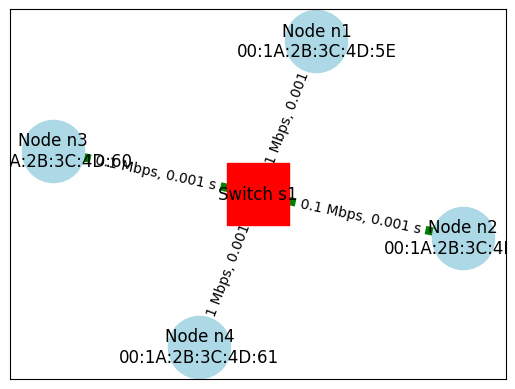

Time: 1.0 Node: n1, Event: created, Packet: b997f07c-eae8-44dd-a1cc-3eefc96bdbbc, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 1.0 Node: n1, Event: sent, Packet: b997f07c-eae8-44dd-a1cc-3eefc96bdbbc, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 1.0 Node: n2, Event: created, Packet: 76e20b10-bc48-4702-9848-f53407e0bc92, Src: 00:1A:2B:3C:4D:5F, Dst: 00:1A:2B:3C:4D:61
Time: 1.0 Node: n2, Event: sent, Packet: 76e20b10-bc48-4702-9848-f53407e0bc92, Src: 00:1A:2B:3C:4D:5F, Dst: 00:1A:2B:3C:4D:61
Time: 1.001 Node: s1, Event: received, Packet: b997f07c-eae8-44dd-a1cc-3eefc96bdbbc, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 1.001 Node: s1, Event: broadcast, Packet: b997f07c-eae8-44dd-a1cc-3eefc96bdbbc, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 1.001 Node: s1, Event: broadcast, Packet: b997f07c-eae8-44dd-a1cc-3eefc96bdbbc, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 1.001 Node: s1, Event: broadcast, Packet: b997f07c-eae8-44dd-a1cc-3eefc96bdbbc, Src: 0

In [2]:
# 必要なクラスをインポートします
from sec4a.NetworkEventScheduler import NetworkEventScheduler
from sec4a.Node import Node
from sec4a.Switch import Switch
from sec4a.Link import Link

network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=True)

# ノードとスイッチの設定
node1 = Node(node_id="n1", mac_address="00:1A:2B:3C:4D:5E", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id="n2", mac_address="00:1A:2B:3C:4D:5F", network_event_scheduler=network_event_scheduler)
node3 = Node(node_id="n3", mac_address="00:1A:2B:3C:4D:60", network_event_scheduler=network_event_scheduler)
node4 = Node(node_id="n4", mac_address="00:1A:2B:3C:4D:61", network_event_scheduler=network_event_scheduler)
switch1 = Switch(node_id="s1", network_event_scheduler=network_event_scheduler)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link2 = Link(node2, switch1, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link3 = Link(node3, switch1, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link4 = Link(node4, switch1, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)

# スイッチのフォワーディングテーブルを設定しない

# ネットワークのトポロジを描画
network_event_scheduler.draw()

# 通信アプリケーションの設定
node1.set_traffic(destination_mac="00:1A:2B:3C:4D:5F", bitrate=1000, start_time=1.0, duration=2.0, burstiness=1.0, header_size=40, payload_size=85)
node2.set_traffic(destination_mac="00:1A:2B:3C:4D:61", bitrate=1000, start_time=1.0, duration=2.0, burstiness=1.0, header_size=40, payload_size=85)

# イベントスケジューラを実行
network_event_scheduler.run()

# 結果を確認
# フォワーディングテーブルを確認
switch1.print_forwarding_table()

# ネットワーク上でのパケットの流れとパフォーマンスに関するサマリを生成
#network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
#network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)
#network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)


### ログの確認

パケットのイベントログを確認してみると、スイッチs1が最初のパケットを受け取った際、以下のようなログが出ています。
知らない宛先MACアドレスのパケットを受け取り、ブロードキャストにより3つのリンクへとコピーして3回転送しています。

```
Time: 1.001 Node: s1, Event: received, Packet: a424125a-ddb4-43e6-beec-2eb250d1c740, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 1.001 Node: s1, Event: broadcast, Packet: a424125a-ddb4-43e6-beec-2eb250d1c740, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 1.001 Node: s1, Event: broadcast, Packet: a424125a-ddb4-43e6-beec-2eb250d1c740, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 1.001 Node: s1, Event: broadcast, Packet: a424125a-ddb4-43e6-beec-2eb250d1c740, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
```

また、フォワーディングテーブルを出力してみると、以下のように表示されています。
パケットを送信してきたノードs1とs2については、MACアドレスを学習しています。
その一方で、ノードs3とs4はパケットを送信していないため、そのMACアドレスを知らないままです。

```
フォワーディングテーブル for Switch s1:
  MACアドレス: 00:1A:2B:3C:4D:5E -> リンク先ノード: n1
  MACアドレス: 00:1A:2B:3C:4D:5F -> リンク先ノード: n2
```


### 課題
1. `Node`と`Switch`を好きなように接続して、ローカルネットワークを構成しましょう。
2. `Node`間でパケット送受信を行い、`Switch`でブロードキャストが行われること、フォワーディングテーブルが作成されることを確認しましょう。
3. パケットを送信するノードを変えながら、フォワーディングテーブルを確認してみましょう。


## スパニングツリープロトコル（STP）

### ループとブロードキャストストーム

フォワーディングテーブルを自動的にアップデートできるようになり、好きなトポロジでネットワークを構成できるようになりました。
ただ、現在の実装ではまだ、問題があります。（もしかしたら、上記の課題でその問題に気づいた方もいるかもしれません）
試しに、以下のコードを実行してみてください。



In [5]:
from sec4a.NetworkEventScheduler import NetworkEventScheduler
from sec4a.Node import Node
from sec4a.Switch import Switch
from sec4a.Link import Link

network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=True)

# ノードとスイッチの設定
node1 = Node(node_id="n1", mac_address="00:1A:2B:3C:4D:5E", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id="n2", mac_address="00:1A:2B:3C:4D:5F", network_event_scheduler=network_event_scheduler)
switch1 = Switch(node_id="s1", network_event_scheduler=network_event_scheduler)
switch2 = Switch(node_id="s2", network_event_scheduler=network_event_scheduler)
switch3 = Switch(node_id="s3", network_event_scheduler=network_event_scheduler)
switch4 = Switch(node_id="s4", network_event_scheduler=network_event_scheduler)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link2 = Link(switch1, switch2, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link3 = Link(switch1, switch3, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link4 = Link(switch1, switch4, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link5 = Link(switch2, switch3, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link6 = Link(switch2, switch4, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link7 = Link(switch3, switch4, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link8 = Link(node2, switch3, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)

# ネットワークのトポロジを描画
network_event_scheduler.draw()

# 通信アプリケーションの設定
node1.set_traffic(destination_mac="00:1A:2B:3C:4D:5F", bitrate=1000, start_time=1.0, duration=2.0, burstiness=1.0, header_size=40, payload_size=85)

# イベントスケジューラを実行
network_event_scheduler.run()

# 結果を確認
# フォワーディングテーブルを確認
switch1.print_forwarding_table()

# ネットワーク上でのパケットの流れとパフォーマンスに関するサマリを生成
#network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
#network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)
#network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)


Output hidden; open in https://colab.research.google.com to view.


さて、どうなったでしょう。
いつまで経っても実行が完了せず、ずっと何か表示され続けてしまったのではないでしょうか。
実行を中断して、改めてログを確認すると、以下のようにパケットの受信とブロードキャストが延々と続いていることが分かります。

```
Time: 4.042000000000001 Node: s1, Event: received, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s1, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s1, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s1, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s1, Event: received, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s1, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s1, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s1, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s1, Event: received, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s1, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s1, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s1, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s2, Event: received, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s2, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s2, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s2, Event: received, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s2, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s2, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s3, Event: received, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s3, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s3, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s3, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s3, Event: received, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s3, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s3, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s3, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s4, Event: received, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s4, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s4, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s4, Event: received, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s4, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s4, Event: broadcast, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
Time: 4.042000000000001 Node: s2, Event: received, Packet: 9da40c32-bd66-4a93-8d30-59ebd6e87097, Src: 00:1A:2B:3C:4D:5E, Dst: 00:1A:2B:3C:4D:5F
```

今回のトポロジでは、ネットワーク内にループがありました。
ループとは閉路、ぐるっと回って一周できるところです。
ネットワーク構成をプロットした図を見返してみると、スイッチ同士がループ接続されていることが分かります。
宛先不明のパケットを受け取ったスイッチは、ブロードキャストにより他のスイッチへとパケットを転送します。
これを受け取ったスイッチ達も、このパケットの宛先を知らないためブロードキャストを行います。
そして最初にブロードキャストを行ったスイッチがブロードキャストパケットを受け取り、再び宛先不明によりブロードキャストするのです。
このようにして、延々とブロードキャストパケットがコピーされ続けるのです。

今回の現象を端的に言うと、「ネットワーク内にループがあると、ブロードキャストが永遠にコピーされ続ける」です。
こうした事象をブロードキャストストームと呼びます。
今回のコードで体験した通り、ブロードキャストストームが実際に起こると大変なことになります。
スイッチの処理能力をオーバして異常が発生することもあれば、最悪ネットワーク全体がダウンすることもあります。

### スパニングツリープロトコル（STP）

このような現象を防ぐための手法が、スパニングツリープロトコル（Spanning Tree Protocol、STP）です。
STPは、ネットワーク内のループを防止するために設計されたプロトコルです。
古典的な手法なので、STPを改良したプロトコルも多く存在しますが、考え方を学ぶには適しています。
STPは、ネットワーク内のスイッチ間で専用のパケットを交換し、リンクを選択的にブロック状態にします。
ブロック（ブロッキング）とは、パケットを送受信しない状態を指します。
つまり物理的には接続されたまま、使用しない、ということです。
ネットワークにループが発生しないようにブロッキングポートを定め、ループのないツリー構造を作ります。
結果として、データパケットの無限ループやブロードキャストストームを防ぐことができます。

### STPの基本的な仕組み
I
1. **ルートブリッジの選出：**
   ネットワーク内の全スイッチの中から、ルート（ツリーの根となるスイッチ）が選出されます。この選出はIDに基づいて行われ、最も低いIDを持つスイッチがルートになります。

2. **パスコストの計算：**
   各スイッチは、ルートブリッジまでのパスコスト（通信経路のコスト）を計算します。パスコストは一般的に、リンクの帯域幅に基づいて計算され、帯域幅が大きいほどコストは低くなります。コストが低いリンクを選んで使うことで、なるべく帯域を大きくする、という考え方です。

3. **ポートの役割の決定：**
   各スイッチは、自身の各ポートに対して役割を割り当てます。役割には、ルートポート（ルートへの最短経路にあるポート）、指定ポート（セグメント上で最小コストのポート）、非指定ポート（ブロッキング状態のポート）があります。

4. **BPDUの交換：**
   スイッチは、ブリッジプロトコルデータユニット（BPDU）と呼ばれる特別なメッセージを交換し、ネットワークのトポロジ情報を共有します。BPDUには、ルートの識別子、パスコスト、送信スイッチの識別子などが含まれます。

5. **アクティブトポロジの維持：**
   STPは、ネットワークの変更があった場合（例えば、リンクの追加や削除）にトポロジを再計算し、ループフリーな状態を維持します。

ポイントは、スイッチ間でBPDUと呼ばれる専用パケットを交換し、一定のルールで各スイッチがルートの選出とブロッキングポートの選択を行うことで、ネットワーク全体として自動的にループを防ぐ、ということです。

### `BPDU`クラスの実装

BPDUは、以下の主要な情報を含む特別な形式のパケットです。

- **ルートID（Root ID）：** ネットワーク内のルートブリッジの識別子。
- **ブリッジID（Bridge ID）：** BPDUを送信するブリッジ（スイッチ）の識別子。
- **パスコスト（Path Cost）：** ルートブリッジまでの通信コスト。

BPDUは、通常のデータパケットとは異なり、ネットワークの管理と制御に特化しています。そのため、BPDUを扱う際には、通常のデータ通信とは異なる特別な処理が必要です。例えば、BPDUは特定の宛先MACアドレス（ブロードキャストアドレス）に送信され、ネットワーク内の全スイッチに到達するように設計されています。

実装に当たっては、既存の`Packet`クラスを継承して実装します。
これは、BPDUは特殊なパケットではありますが、一般的なパケットの特性（送信元、宛先、サイズなど）を共有しているためです。
またBPDU固有の情報（ルートID、ブリッジID、パスコスト）は、ペイロードとして追加され、スイッチ間で共有することでトポロジの計算を実行します。


In [ ]:
import uuid

class BPDU(Packet):
    def __init__(self, source_mac, destination_mac, root_id, bridge_id, path_cost, network_event_scheduler):
        # Packetクラスのコンストラクタを呼び出す
        # ここで、BPDUはPacketクラスを継承しているため、Packetクラスの初期化処理を利用します。
        # source_macとdestination_macはBPDUの送信元と宛先のMACアドレスです。
        # header_sizeとpayload_sizeはBPDUのヘッダとペイロードのサイズを指定します。
        super().__init__(source_mac, destination_mac, header_size=20, payload_size=50, network_event_scheduler=network_event_scheduler)

        # BPDU特有のペイロード情報を追加
        # このペイロードには、STPの計算に必要な情報が含まれます。
        # root_idはネットワーク内のルートブリッジの識別子、
        # bridge_idはこのBPDUを送信するブリッジの識別子、
        # path_costはルートブリッジまでのパスコストです。
        self.payload = {
            "root_id": root_id,
            "bridge_id": bridge_id,
            "path_cost": path_cost
        }

    def __str__(self):
        # BPDUの文字列表現をカスタマイズ
        # このメソッドは、BPDUオブジェクトを文字列として表示する際に使用されます。
        # 例えば、print関数でBPDUオブジェクトを出力するときにこの形式が使用されます。
        return f'BPDU(送信元: {self.header["source_mac"]}, 宛先: {self.header["destination_mac"]}, ルートID: {self.payload["root_id"]}, ブリッジID: {self.payload["bridge_id"]}, パスコスト: {self.payload["path_cost"]})'


### `Switch`クラスのアップデート

`Switch`クラスをアップデートし、STPに対応できるようにします。
その主要な機能とその実装方法について解説します。

#### 主要な機能と実装方法

1. **初期化とBPDUの送信**
   - `__init__`メソッドでスイッチを初期化し、各リンクに対して初期状態を設定します。
   - `add_link`メソッドで新しいリンクを追加し、STPプロセスを開始します。これには、BPDU（Bridge Protocol Data Unit）を生成し、ネットワーク内の他のスイッチに送信する処理が含まれます。

```
class Switch:
    def __init__(self, node_id, network_event_scheduler):
        # スイッチの初期化
        self.network_event_scheduler = network_event_scheduler  # ネットワークイベントスケジューラへの参照
        self.node_id = node_id  # スイッチのID
        self.links = []  # スイッチに接続されているリンクのリスト
        self.forwarding_table = {}  # MACアドレスに基づいてパケットを転送するためのフォワーディングテーブル
        self.link_states = {}  # リンクの状態を管理する辞書
        self.root_id = node_id  # 初期状態では自身をルートと仮定
        self.root_path_cost = 0  # ルートまでのパスコスト
        self.is_root = True  # 初期状態では自身がルートブリッジ
        label = f'Switch {node_id}'  # ネットワーク図に表示されるスイッチのラベル
        self.network_event_scheduler.add_node(node_id, label)  # スイッチをネットワーク図に追加

    def add_link(self, link):
        # リンクが既にリストに存在しない場合のみ追加
        if link not in self.links:
            self.links.append(link)
            self.link_states[link] = 'initial'  # 初期状態を設定
            # ネットワークの安定性を確認した後、STPプロセスを開始
            # （実際の実装では、条件に応じてSTPプロセスを制御する）
            self.send_bpdu()

    def send_bpdu(self):
        for link in self.links:
            # BPDUの作成
            bpdu = BPDU(source_mac="00:00:00:00:00:00",  # 送信元MACアドレス（ダミーまたはスイッチのMACアドレス）
                      destination_mac="FF:FF:FF:FF:FF:FF",  # 宛先MACアドレス（ブロードキャストアドレス）
                      root_id=self.root_id,
                      bridge_id=self.node_id,
                      path_cost=self.root_path_cost,
                      network_event_scheduler=self.network_event_scheduler)
            link.enqueue_packet(bpdu, self)
```

2. **BPDUの処理**
   - `receive_packet`メソッドでは、受信したパケットがBPDUかどうかを判断し、BPDUの場合は`process_bpdu`メソッドを呼び出します。
   - `process_bpdu`メソッドでは、受信したBPDUに基づいてルートブリッジの情報を更新し、必要に応じてリンクの状態を更新します。

```
    def receive_packet(self, packet, received_link):
        if isinstance(packet, BPDU):
            self.network_event_scheduler.log_packet_info(packet, "BPDU received", self.node_id)  # パケット受信をログに記録
            self.process_bpdu(packet, received_link)
        else:
            # パケットを受信
            if packet.arrival_time == -1:
                self.network_event_scheduler.log_packet_info(packet, "lost", self.node_id)  # パケットが失われた場合の処理
                return
            self.network_event_scheduler.log_packet_info(packet, "received", self.node_id)  # パケット受信をログに記録

            # 送信元MACアドレスを学習
            source_address = packet.header["source_mac"]
            self.update_forwarding_table(source_address, received_link)  # フォワーディングテーブルを更新

            # パケットを転送
            self.forward_packet(packet, received_link)

    def process_bpdu(self, bpdu, received_link):
        # ルートIDの更新とルートパスコストの計算
        new_root_id = bpdu.payload["root_id"]
        new_path_cost = bpdu.payload["path_cost"] + 1  # 受信リンクを通るコストを加算

        # ルート情報が変更されたかどうかを確認
        root_info_changed = new_root_id != self.root_id or new_path_cost < self.root_path_cost

        if self.network_event_scheduler.stp_verbose:
            current_time = self.network_event_scheduler.current_time
            print(f"Time: {current_time} - {self.node_id} processing BPDU: new_root_id={new_root_id}, current_root_id={self.root_id}, new_path_cost={new_path_cost}, current_root_path_cost={self.root_path_cost}")

        if new_root_id < self.root_id or (new_root_id == self.root_id and new_path_cost < self.root_path_cost):
            # ルート情報の更新
            self.root_id = new_root_id
            self.root_path_cost = new_path_cost
            self.is_root = False

        # リンク状態の更新（例：フォワーディング/ブロッキング）
        self.update_link_states(received_link, new_path_cost)

        # ルート情報が変更された場合のみBPDUを再送信
        if root_info_changed:
            self.send_bpdu()
```

3. **リンク状態の管理**
   - `update_link_states`メソッドでは、スイッチがルートブリッジかどうかに基づいて、各リンクの状態（フォワーディングまたはブロッキング）を更新します。
   - スイッチ間のリンクのみをブロッキングするために、`is_link_between_switches`メソッドを使用してリンクの種類を判断します。

```
    def update_link_states(self, received_link, received_bpdu_path_cost):
        if self.is_root:
            # ルートブリッジの場合、全てのポートをフォワーディング状態に設定
            for link in self.links:
                self.link_states[link] = 'forwarding'
        else:
            # 非ルートブリッジの場合、最小コストのリンクを選択してフォワーディングに設定
            best_path_cost = float('inf')
            best_link = None
            best_link_id = None

            for link in self.links:
                if self.is_link_between_switches(link):
                    link_path_cost = self.get_link_cost(link) + received_bpdu_path_cost
                    link_id = min(link.node_x.node_id, link.node_y.node_id)
                    if link_path_cost < best_path_cost or (link_path_cost == best_path_cost and link_id < best_link_id):
                        best_path_cost = link_path_cost
                        best_link = link
                        best_link_id = link_id

            for link in self.links:
                if link == best_link or not self.is_link_between_switches(link):
                    self.link_states[link] = 'forwarding'
                else:
                    self.link_states[link] = 'blocking'

            if self.network_event_scheduler.stp_verbose:
                print(f"{self.node_id} link states updated: {self.link_states}")

    def is_link_between_switches(self, link):
        # リンクがスイッチ間のリンクかどうかを判定する
        return isinstance(link.node_x, Switch) and isinstance(link.node_y, Switch)

    def get_link_cost(self, link):
        # リンクのコストを帯域幅の逆数として計算
        # ただし、0除算を避けるために最小コストを設定
        min_cost = 0.000000001  # 最小コスト
        return max(min_cost, 1.0 / link.bandwidth)
```

4. **パケットの転送**
   - `forward_packet`メソッドでは、宛先MACアドレスに基づいてパケットを適切なリンクに転送します。ただし、リンクの状態がフォワーディングである場合に限ります。

```
    def forward_packet(self, packet, received_link):
        # パケットを転送
        destination_address = packet.header["destination_mac"]
        if destination_address in self.forwarding_table:
            # 宛先がフォワーディングテーブルにある場合、そのリンクに転送
            link = self.forwarding_table[destination_address]
            if self.link_states[link] == 'forwarding':  # リンクの状態がforwardingの場合のみ転送
                self.network_event_scheduler.log_packet_info(packet, "forwarded", self.node_id)
                link.enqueue_packet(packet, self)
        else:
            # 宛先が不明の場合、ブロードキャスト
            for link in self.links:
                if link != received_link and self.link_states[link] == 'forwarding':  # リンクの状態がforwardingで、受信リンク以外にブロードキャスト
                    self.network_event_scheduler.log_packet_info(packet, "broadcast", self.node_id)
                    link.enqueue_packet(packet, self)
```

5. **フォワーディングテーブルの管理**
   - `update_forwarding_table`メソッドで、学習したMACアドレスとリンクの関連付けをフォワーディングテーブルに保存します。

```
    def update_forwarding_table(self, source_address, link):
        # フォワーディングテーブルを更新（学習）
        self.forwarding_table[source_address] = link  # 送信元アドレスとリンクの関連付けを保存
```

6. **デバッグと可視化**
   - STPの動作を理解しやすくするために、`print_forwarding_table`と`print_link_states`メソッドを実装し、フォワーディングテーブルとリンクの状態を出力できるようにします。

```
    def print_forwarding_table(self):
        # フォワーディングテーブルの内容を表示するメソッド
        print(f"フォワーディングテーブル for Switch {self.node_id}:")
        for mac_address, link in self.forwarding_table.items():
            linked_node = link.node_x.node_id if link.node_x.node_id != self.node_id else link.node_y.node_id
            print(f"  MACアドレス: {mac_address} -> リンク先ノード: {linked_node}")

    def print_link_states(self):
        # 各リンクの状態を出力
        print(f"スイッチ {self.node_id} （root={self.is_root}）のリンク状態:")
        for link in self.links:
            state = self.link_states[link]
            connected_node = link.node_x if link.node_x != self else link.node_y
            print(f"  - リンク {self.node_id} - {connected_node.node_id}: 状態 {state}")
```

なお、実際のSTPでは一定時間ごとにBPDUを送受信してリンク状態をアップデートする処理が行われます。
あまり煩雑にすると分かりにくくなってしまうため、今回はそのような処理は省略しており、シミュレーション開始時にのみBPDUを交換します。



### STPの動作確認

アップデートした`Switch`クラスと`BPDU`クラスを利用して、STPによるブロッキングを模擬して確認してみます。
以下に、今回のポイントを説明します。

#### NetworkEventSchedulerの初期化
```python
network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=False, stp_verbose=True)
```
- `NetworkEventScheduler`は、ネットワークイベント（パケットの送受信、BPDUの処理など）を管理するためのクラスです。
- `log_enabled=True`は、イベントのログ記録を有効にします。
- `verbose=False`は、一般的なイベントログの詳細度を標準に設定します。
- `stp_verbose=True`は、STP関連のイベントについてより詳細なログを有効にします。この設定は、STPのプロセスとその影響をより深く理解するのに役立ちます。

#### リンク状態の確認
```python
switch1.print_link_states()
switch2.print_link_states()
switch3.print_link_states()
switch4.print_link_states()
```
- この部分では、各スイッチのリンク状態をコンソールに出力します。
- `print_link_states`メソッドは、スイッチに接続されている各リンクの状態（フォワーディングまたはブロッキング）を表示します。これはSTPによって決定され、ネットワーク内のループを防ぐために特定のリンクをブロッキング状態に設定します。

#### リンク状態の可視化
```python
switches = [switch1, switch2, switch3, switch4]
network_event_scheduler.draw_with_link_states(switches)
```
- ここでは、ネットワークのトポロジとともに、リンクの状態（フォワーディングまたはブロッキング）を視覚的に表示します。
- `draw_with_link_states`メソッドは、ネットワーク図上でリンクの状態を色分けして示します。これにより、どのリンクがデータ転送に使用されているか（フォワーディング＝緑）、どのリンクがブロックされているか（ブロッキング＝赤）が一目でわかります。

#### フォワーディングテーブルの確認
```python
switch1.print_forwarding_table()
switch2.print_forwarding_table()
switch3.print_forwarding_table()
switch4.print_forwarding_table()
```
- 各スイッチのフォワーディングテーブルの内容を表示します。今回はデータパケットを送信していないため、空のままであることを確認します。


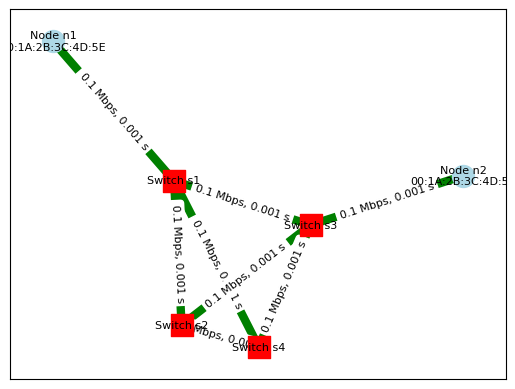

Time: 0.001 - s2 processing BPDU: new_root_id=s1, current_root_id=s2, new_path_cost=1, current_root_path_cost=0
s2 link states updated: {<sec4b.Link.Link object at 0x7c474c7e1540>: 'forwarding', <sec4b.Link.Link object at 0x7c474c7e1570>: 'blocking', <sec4b.Link.Link object at 0x7c474c7e1bd0>: 'blocking'}
Time: 0.001 - s1 processing BPDU: new_root_id=s2, current_root_id=s1, new_path_cost=1, current_root_path_cost=0
Time: 0.001 - s3 processing BPDU: new_root_id=s1, current_root_id=s3, new_path_cost=1, current_root_path_cost=0
s3 link states updated: {<sec4b.Link.Link object at 0x7c474c7e1840>: 'forwarding', <sec4b.Link.Link object at 0x7c474c7e1570>: 'blocking', <sec4b.Link.Link object at 0x7c474c7e1330>: 'blocking', <sec4b.Link.Link object at 0x7c474c7e13f0>: 'forwarding'}
Time: 0.001 - s1 processing BPDU: new_root_id=s3, current_root_id=s1, new_path_cost=1, current_root_path_cost=0
Time: 0.001 - s4 processing BPDU: new_root_id=s1, current_root_id=s4, new_path_cost=1, current_root_path

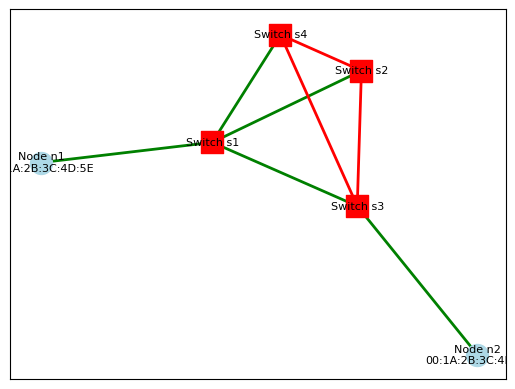

フォワーディングテーブル for Switch s1:
フォワーディングテーブル for Switch s2:
フォワーディングテーブル for Switch s3:
フォワーディングテーブル for Switch s4:


In [6]:
from sec4b.NetworkEventScheduler import NetworkEventScheduler
from sec4b.Node import Node
from sec4b.Switch import Switch
from sec4b.Link import Link

network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=False, stp_verbose=True)

# ノードとスイッチの設定
node1 = Node(node_id="n1", mac_address="00:1A:2B:3C:4D:5E", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id="n2", mac_address="00:1A:2B:3C:4D:5F", network_event_scheduler=network_event_scheduler)
switch1 = Switch(node_id="s1", network_event_scheduler=network_event_scheduler)
switch2 = Switch(node_id="s2", network_event_scheduler=network_event_scheduler)
switch3 = Switch(node_id="s3", network_event_scheduler=network_event_scheduler)
switch4 = Switch(node_id="s4", network_event_scheduler=network_event_scheduler)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link2 = Link(switch1, switch2, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link3 = Link(switch1, switch3, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link4 = Link(switch1, switch4, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link5 = Link(switch2, switch3, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link6 = Link(switch2, switch4, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link7 = Link(switch3, switch4, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link8 = Link(node2, switch3, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)

# ネットワークのトポロジを描画
network_event_scheduler.draw()

# 通信アプリケーションの設定
#node1.set_traffic(destination_mac="00:1A:2B:3C:4D:5F", bitrate=1000, start_time=1.0, duration=2.0, burstiness=1.0, header_size=40, payload_size=85)

# イベントスケジューラを実行
network_event_scheduler.run()

# 結果を確認
# リンクの状態を確認
switch1.print_link_states()
switch2.print_link_states()
switch3.print_link_states()
switch4.print_link_states()
# リンクの状態を可視化
switches = [switch1, switch2, switch3, switch4]
network_event_scheduler.draw_with_link_states(switches)

# フォワーディングテーブルを確認
switch1.print_forwarding_table()
switch2.print_forwarding_table()
switch3.print_forwarding_table()
switch4.print_forwarding_table()

# ネットワーク上でのパケットの流れとパフォーマンスに関するサマリを生成
#network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
#network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)
#network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)


STPにより、s1をrootとしたツリーが形成され、ループが回避されていることが分かります。
また過剰にブロックすることもなく、到達不可能なノードがないことも確認しておきましょう。
あとは、この状態でパケットを送信したときにブロードキャストストームが起こらないことを確かめていきます。
シミュレーション開始からしばらくはBPDUの交換が行われ、正常な通信ができないことから、トラフィックのstart_timeを1秒に設定しています。


スイッチ s1 （root=True）のリンク状態:
  - リンク s1 - n1: 状態 forwarding
  - リンク s1 - s2: 状態 forwarding
  - リンク s1 - s3: 状態 forwarding
  - リンク s1 - s4: 状態 forwarding
スイッチ s2 （root=False）のリンク状態:
  - リンク s2 - s1: 状態 forwarding
  - リンク s2 - s3: 状態 blocking
  - リンク s2 - s4: 状態 blocking
スイッチ s3 （root=False）のリンク状態:
  - リンク s3 - s1: 状態 forwarding
  - リンク s3 - s2: 状態 blocking
  - リンク s3 - s4: 状態 blocking
  - リンク s3 - n2: 状態 forwarding
スイッチ s4 （root=False）のリンク状態:
  - リンク s4 - s1: 状態 forwarding
  - リンク s4 - s2: 状態 blocking
  - リンク s4 - s3: 状態 blocking


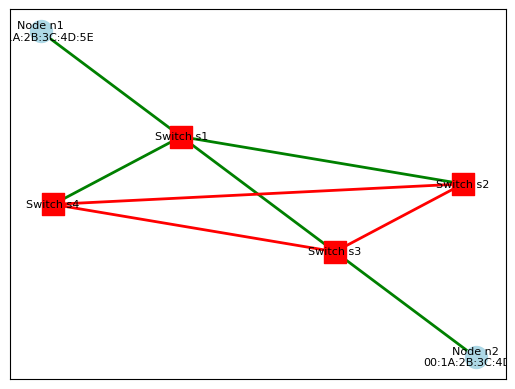

フォワーディングテーブル for Switch s1:
  MACアドレス: 00:1A:2B:3C:4D:5E -> リンク先ノード: n1
フォワーディングテーブル for Switch s2:
  MACアドレス: 00:1A:2B:3C:4D:5E -> リンク先ノード: s1
フォワーディングテーブル for Switch s3:
  MACアドレス: 00:1A:2B:3C:4D:5E -> リンク先ノード: s1
フォワーディングテーブル for Switch s4:
  MACアドレス: 00:1A:2B:3C:4D:5E -> リンク先ノード: s1
Src-Dst Pair: ('00:00:00:00:00:00', 'FF:FF:FF:FF:FF:FF')
Total Sent Packets: 118
Total Sent Bytes: 8260
Total Received Packets: 0
Total Received Bytes: 0
Average Throughput (bps): 0
Average Delay (s): 0
Lost Packets: 118

Src-Dst Pair: ('00:1A:2B:3C:4D:5E', '00:1A:2B:3C:4D:5F')
Total Sent Packets: 109
Total Sent Bytes: 13625
Total Received Packets: 109
Total Received Bytes: 13625
Average Throughput (bps): 21786.927843294037
Average Delay (s): 0.0030000000000002074
Lost Packets: 0



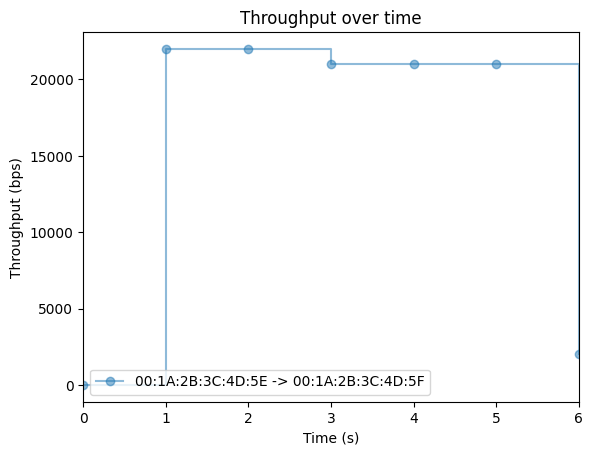

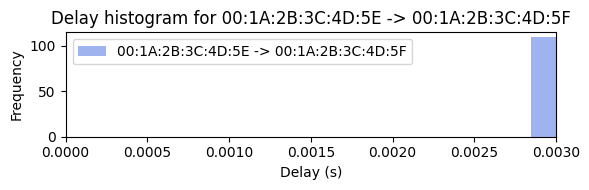

In [ ]:
# 通信アプリケーションの設定
node1.set_traffic(destination_mac="00:1A:2B:3C:4D:5F", bitrate=10000, start_time=1.0, duration=5.0, burstiness=1.0, header_size=40, payload_size=85)

# イベントスケジューラを実行
network_event_scheduler.run()

# 結果を確認
# リンクの状態を確認
switch1.print_link_states()
switch2.print_link_states()
switch3.print_link_states()
switch4.print_link_states()
# リンクの状態を可視化
switches = [switch1, switch2, switch3, switch4]
network_event_scheduler.draw_with_link_states(switches)

# フォワーディングテーブルを確認
switch1.print_forwarding_table()
switch2.print_forwarding_table()
switch3.print_forwarding_table()
switch4.print_forwarding_table()

# ネットワーク上でのパケットの流れとパフォーマンスに関するサマリを生成
network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)
network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)


### 課題

### 演習課題1: 複数スイッチを用いたネットワーク構築
**目的**: 複数のノードとスイッチを使用して、ローカルネットワークを構築し、基本的なネットワーク構造と接続方法を理解する。

**手順**:
1. 複数のノードと複数のスイッチを使用して、ローカルネットワークを構築します。
2. 各ノードに一意のMACアドレスを付与します。

### 演習課題2: STPの確認
**目的**: STPを使用してネットワーク内のループを回避し、ネットワークの冗長性と安定性を理解する。

**手順**:
1. 複数のスイッチ間で冗長なリンクを持つネットワークを構築し、STPがどのようにループを防止するかを観察します。
2. スイッチのIDを変えて、STPによるブロッキングがどのように変わるかを観察します。

### 演習課題3: パケット送受信とフォワーディングテーブルの観察
**目的**: ノード間でパケットの送受信を行い、スイッチのフォワーディングテーブルの動作を理解する。

**手順**:
1. ノード間でパケットを送受信し、スイッチがどのようにフォワーディングテーブルを使用してパケットを適切な宛先に転送するかを観察します。
2. ネットワーク上でのパケットの流れを追跡し、ブロードキャストトラフィックがどのように処理されるかを理解します。


## 本章のまとめ

本章では、スイッチの主要機能であるMACアドレス学習とブロードキャストを実装しながら学習しました。
アドレスを自ら学習する仕組みを備えるため、手動でフォワーディングテーブルを設定する必要がないのです。
また有名な問題であるブロードキャストストームについても、実際に体感することができたと思います。
このように体感することで理解を深められる点が、作りながら学ぶことのメリットだと思います。
さらに、ブロードキャストストームを防ぐプロトコルであるSTPも実装して動作を確認しました。
これでノードとスイッチからなるローカルネットワークの基本的な動作を模擬することができるようになりました。
ぜひ、色々なトポロジを組んで試してみていただけたら、と思います。
